In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r'C:\Users\ACER\Desktop\Projects\Machine Learning Based Real Estate System\Dataset\Cleaned_Properties_V3.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7502.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,3.0,NaN,New Property,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12545.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,10.0,North-East,Relatively New,1395.0,NaN,809.0,0,1,0,0,0,0,124
2,house,suncity township,sector 54,2.00,3440.0,5814.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,11.0,North,Relatively New,NaN,60.0,59.0,0,1,0,0,0,2,7
3,house,independent,sector 108,1.70,5667.0,3000.0,Built Up area: 3000 (278.71 sq.m.)Carpet area:...,4,4,3+,1.0,North-East,Undefined,NaN,3000.0,2600.0,0,0,0,0,0,1,0
4,flat,dlf the ultima,sector 81,2.30,10994.0,2092.0,Super Built up area 2092(194.35 sq.m.),3,4,3+,6.0,East,New Property,2092.0,NaN,NaN,0,1,0,0,0,2,167


In [4]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1048
agePossession             0
super_built_up_area    1753
built_up_area          1980
carpet_area            1767
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

### Built Up Area

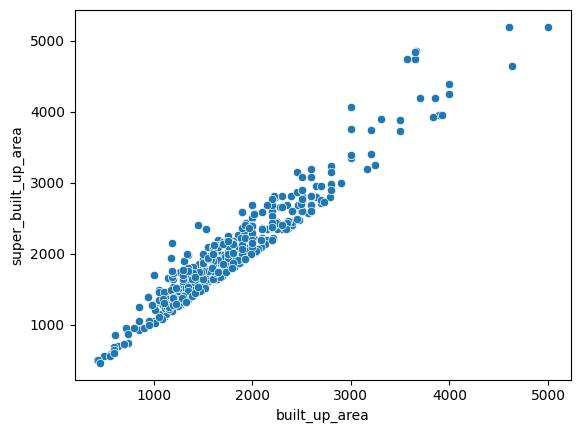

In [6]:
sns.scatterplot(data=df, x='built_up_area', y='super_built_up_area')
plt.show()

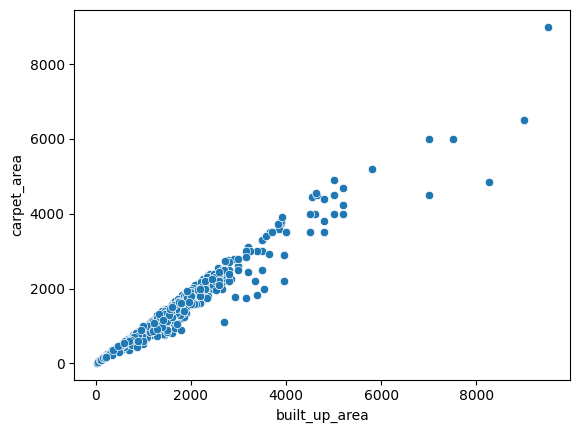

In [7]:
sns.scatterplot(data=df, x='built_up_area', y='carpet_area')
plt.show()

In [8]:
(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())

0       False
1       False
2       False
3       False
4       False
        ...  
3628    False
3629    False
3630    False
3631    False
3632    False
Length: 3633, dtype: bool

In [9]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [10]:
all_present_df.shape

(533, 23)

In [11]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [12]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [13]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [14]:
### Both Present Built Up Null

sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [15]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1,flat,emaar mgf emerald estate,sector 65,1.75,12545.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,10.0,North-East,Relatively New,1395.0,NaN,809.0,0,1,0,0,0,0,124
17,flat,godrej oasis,sector 88a,1.45,8367.0,1733.0,Super Built up area 161Carpet area: 108.4 sq.m.,2,2,3+,9.0,NaN,Relatively New,161.0,NaN,108.4,1,0,0,0,0,2,85
29,flat,chintels paradiso,sector 109,1.80,8867.0,2030.0,Super Built up area 2030(188.59 sq.m.)Carpet a...,3,3,2,0.0,East,Moderately New,2030.0,NaN,1785.0,0,1,0,0,0,1,83
30,flat,umang winter hills,sector 77,1.10,5296.0,2077.0,Super Built up area 2077(192.96 sq.m.)Carpet a...,3,4,3+,9.0,North,Relatively New,2077.0,NaN,1600.0,0,1,0,0,0,1,49
31,flat,shree vardhman victoria,sector 70,1.75,8204.0,2133.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,7.0,NaN,New Property,1950.0,NaN,1161.0,0,1,0,1,0,1,37


In [16]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2), inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_6412\3548745466.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2), inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_6412\3548745466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [17]:
df.update(sbc_df)

In [18]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1048
agePossession             0
super_built_up_area    1753
built_up_area          1559
carpet_area            1767
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [19]:
# SB Present C in Null Built Up Null

sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [20]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
4,flat,dlf the ultima,sector 81,2.30,10994.0,2092.0,Super Built up area 2092(194.35 sq.m.),3,4,3+,6.0,East,New Property,2092.0,NaN,NaN,0,1,0,0,0,2,167
6,flat,conscient heritage max,sector 102,2.65,10376.0,2554.0,Super Built up area 2554(237.27 sq.m.),4,5,3+,17.0,North,Moderately New,2554.0,NaN,NaN,0,1,0,0,0,1,125
8,flat,antriksh heights,sector 84,0.60,5000.0,1200.0,Super Built up area 1200(111.48 sq.m.),2,2,2,14.0,North,Relatively New,1200.0,NaN,NaN,0,0,0,0,0,1,52
16,flat,dlf the ultima,sector 81,3.45,12013.0,2872.0,Super Built up area 2872(266.82 sq.m.),4,4,3+,10.0,East,New Property,2872.0,NaN,NaN,0,1,0,0,0,2,165
18,flat,landmark the residency,sector 103,0.90,6667.0,1350.0,Super Built up area 1350(125.42 sq.m.),2,2,2,1.0,South-West,Relatively New,1350.0,NaN,NaN,0,0,0,0,0,1,44


In [21]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105), inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_6412\1215299602.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105), inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_6412\1215299602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(

In [22]:
df.update(sb_df)

In [23]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1048
agePossession             0
super_built_up_area    1753
built_up_area           682
carpet_area            1767
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [26]:
# SB Null C is Present Built Up Null

c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [27]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7502.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,3.0,NaN,New Property,NaN,NaN,1340.00,0,0,0,0,0,1,74
5,flat,la vida by tata housing,sector 113,1.50,11755.0,1276.0,Carpet area: 1276 (118.54 sq.m.),2,2,2,13.0,NaN,New Property,NaN,NaN,1276.00,0,0,0,0,0,1,71
7,flat,godrej summit,sector 104,1.20,8299.0,1446.0,Carpet area: 1446 (134.34 sq.m.),3,2,3+,16.0,NaN,Relatively New,NaN,NaN,1446.00,1,0,0,1,0,0,142
10,flat,signature global orchard avenue,sector 93,0.40,7353.0,544.0,Carpet area: 543.53 (50.5 sq.m.),2,2,2,11.0,NaN,New Property,NaN,NaN,543.53,0,0,0,0,0,1,37
13,flat,shri ram apartments,sector 4,0.46,5111.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,1.0,East,Relatively New,NaN,NaN,900.00,0,0,0,0,0,0,69


In [28]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9), inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_6412\3473321853.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9), inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_6412\3473321853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_

In [29]:
df.update(c_df)

In [30]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1048
agePossession             0
super_built_up_area    1753
built_up_area             0
carpet_area            1767
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

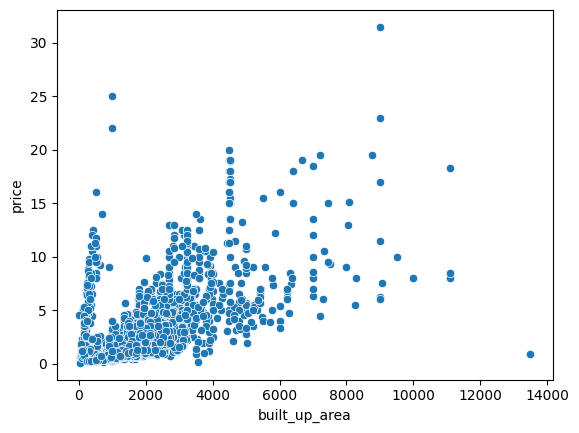

In [31]:
sns.scatterplot(data=df, x='built_up_area', y='price')
plt.show()

In [32]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price', 'area', 'built_up_area']]

In [33]:
anamoly_df.sample(5)

,price,area,built_up_area
2335,25.00,8036.0,1000.0
2162,2.95,1845.0,1845.0
880,3.67,2040.0,1846.0
40,3.15,2153.0,222.0
3603,3.50,1350.0,1500.0


In [34]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [35]:
df.update(anamoly_df)

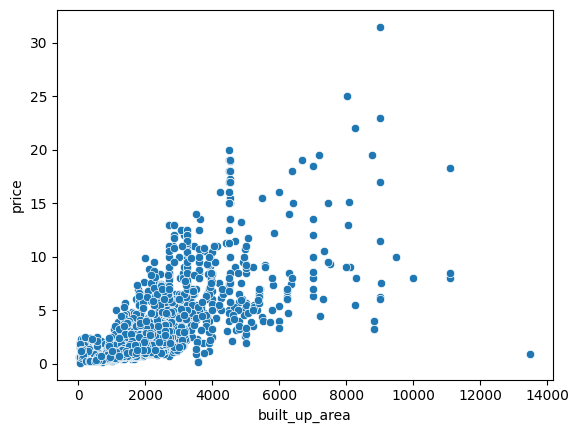

In [36]:
sns.scatterplot(data=df, x='built_up_area', y='price')
plt.show()

In [38]:
df.drop(columns=['area', 'areaWithType', 'super_built_up_area', 'carpet_area'], inplace=True)

In [39]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7502.0,2,2,2,3.0,NaN,New Property,1489.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12545.0,3,3,3,10.0,North-East,Relatively New,1081.0,0,1,0,0,0,0,124
2,house,suncity township,sector 54,2.00,3440.0,9,9,3,11.0,North,Relatively New,60.0,0,1,0,0,0,2,7
3,house,independent,sector 108,1.70,5667.0,4,4,3+,1.0,North-East,Undefined,3000.0,0,0,0,0,0,1,0
4,flat,dlf the ultima,sector 81,2.30,10994.0,3,4,3+,6.0,East,New Property,1893.0,0,1,0,0,0,2,167


In [40]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             19
facing             1048
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [41]:
df.shape

(3633, 19)

### FloorNum

In [42]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
11,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,1,0
12,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately New,3240.0,1,1,1,1,0,1,0
50,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately New,3240.0,0,1,1,1,0,1,88
457,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,1,28
610,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,0,114
627,house,independent,sector 105,1.10,8148.0,2,2,1,NaN,NaN,Old Property,150.0,0,0,0,0,1,1,0
653,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,1,0
816,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately New,585.0,0,0,0,0,0,1,0
982,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,1,59
1029,house,independent,sector 110a,2.50,5472.0,3,2,1,NaN,NaN,Old Property,4000.0,0,0,0,0,0,1,8


In [43]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [44]:
df['floorNum'].fillna(2.0, inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_6412\721975971.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0, inplace=True)


In [45]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1048
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [46]:
1011/df.shape[0]

0.2782824112303881

### facing

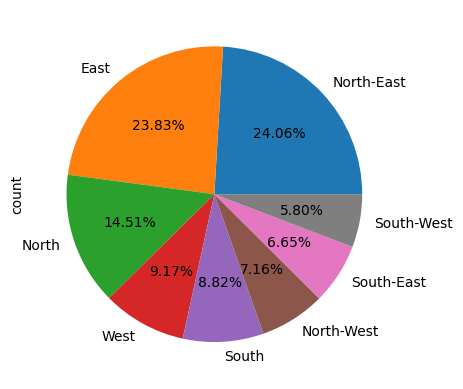

In [47]:
df['facing'].value_counts().plot(kind='pie', autopct='%0.2f%%')
plt.show()

In [48]:
df.drop(columns=['facing'], inplace=True)

In [49]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1459,flat,smart world gems,sector 89,1.00,9009.0,2,2,3,3.0,New Property,1233.0,1,0,0,0,1,1,99
2207,flat,sukhshanti apartment,sector 56,1.70,7727.0,3,3,3,4.0,Moderately New,2200.0,1,0,0,0,0,1,49
430,flat,pyramid urban homes 2,sector 86,0.50,9615.0,2,2,1,10.0,Relatively New,578.0,0,0,0,0,0,1,15
1366,house,independent,sector 41,4.25,26235.0,10,9,3+,4.0,Moderately New,1620.0,1,1,0,0,0,0,36
3255,flat,dlf new town heights,sector 90,1.90,6967.0,4,4,3+,19.0,Relatively New,2512.0,0,1,1,0,0,0,174


In [50]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [53]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1856,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,1,0


In [54]:
df.drop(index=[1856], inplace=True)

In [55]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [56]:
df['agePossession'].value_counts()

agePossession
Relatively New        1757
New Property           590
Moderately New         559
Old Property           315
Undefined              313
Under Construction      98
Name: count, dtype: int64

In [57]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3,house,independent,sector 108,1.70,5667.0,4,4,3+,1.0,Undefined,3000.0,0,0,0,0,0,1,0
70,flat,tulip orange,sector 70,1.10,8148.0,3,2,2,5.0,Undefined,1350.0,0,0,0,0,0,1,0
74,flat,global hill view,sector 11,0.36,5150.0,2,2,0,15.0,Undefined,699.0,0,0,0,0,0,1,0
87,flat,central park flower valley,sector 33,2.50,13270.0,3,3,2,1.0,Undefined,2093.0,0,0,0,0,0,1,66
91,flat,supertech araville,sector 79,0.90,6950.0,2,2,0,12.0,Undefined,1295.0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3567,flat,trisara our homes 3,sohna road road,0.40,4479.0,2,2,2,1.0,Undefined,900.0,0,0,0,0,0,1,0
3578,flat,sare crescent parc royal greens phase 1,sector 92,0.50,5000.0,2,2,3,2.0,Undefined,1000.0,0,0,0,0,0,1,0
3589,house,independent,sector 3,0.55,5000.0,2,1,0,1.0,Undefined,1100.0,0,0,0,0,0,1,0
3609,house,independent,sector 9,1.65,18333.0,2,3,0,3.0,Undefined,900.0,0,0,0,0,0,1,0


In [58]:
def mode_base_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        
        if not mode_value.empty:
            return mode_value.iloc[0]
        
        else:
            return np.nan
    
    else:
        return row['agePossession']

In [59]:
df['agePossession'] = df.apply(mode_base_imputation, axis=1)

In [60]:
df['agePossession'].value_counts()

agePossession
Relatively New        1882
New Property           637
Moderately New         603
Old Property           362
Under Construction      98
Undefined               50
Name: count, dtype: int64

In [61]:
def mode_base_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        
        if not mode_value.empty:
            return mode_value.iloc[0]
        
        else:
            return np.nan
    
    else:
        return row['agePossession']

In [63]:
df['agePossession'] = df.apply(mode_base_imputation2, axis=1)

In [64]:
df['agePossession'].value_counts()

agePossession
Relatively New        1906
New Property           637
Moderately New         609
Old Property           362
Under Construction      98
Undefined               20
Name: count, dtype: int64

In [66]:
def mode_base_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        
        if not mode_value.empty:
            return mode_value.iloc[0]
        
        else:
            return np.nan
    
    else:
        return row['agePossession']

In [67]:
df['agePossession'] = df.apply(mode_base_imputation3, axis=1)

In [68]:
df['agePossession'].value_counts()

agePossession
Relatively New        1906
New Property           637
Moderately New         629
Old Property           362
Under Construction      98
Name: count, dtype: int64

In [69]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [71]:
df.shape

(3632, 18)

In [72]:
df.to_csv('Cleaned_Properties_V4.csv', index=False)